In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings('ignore')

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df.shape

(284807, 31)

In [8]:
df.duplicated().sum()

np.int64(1081)

In [10]:
df.isnull().sum().sum()

np.int64(0)

# Data Cleaning

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum().sum()

np.int64(0)

In [14]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

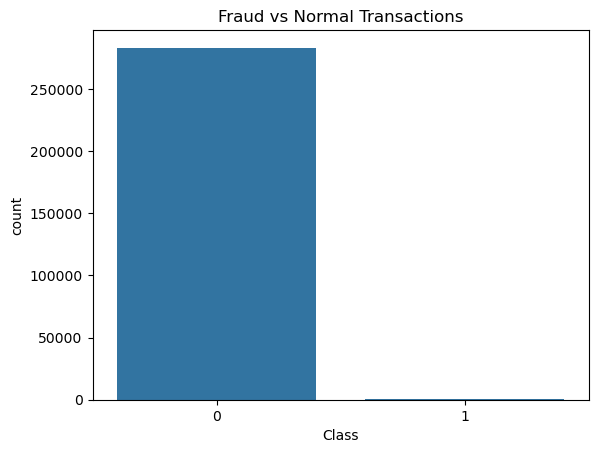

In [17]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [18]:
fraud_percent = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"Fraud Percentage: {fraud_percent:.4f}%")

Fraud Percentage: 0.1667%


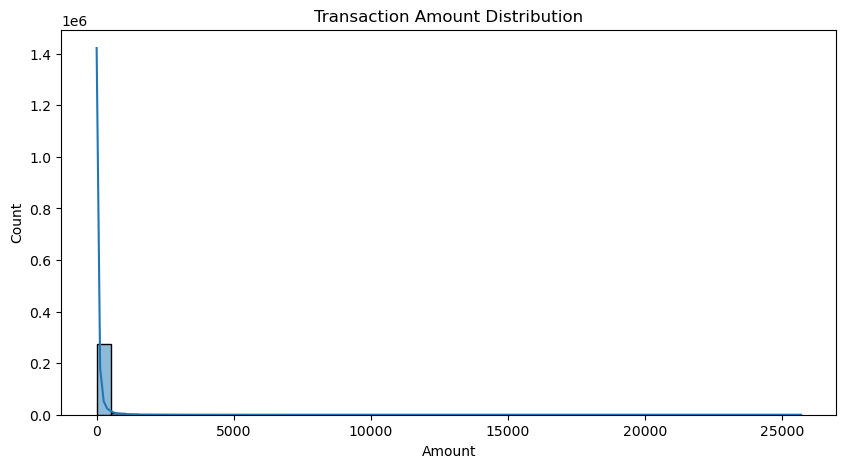

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

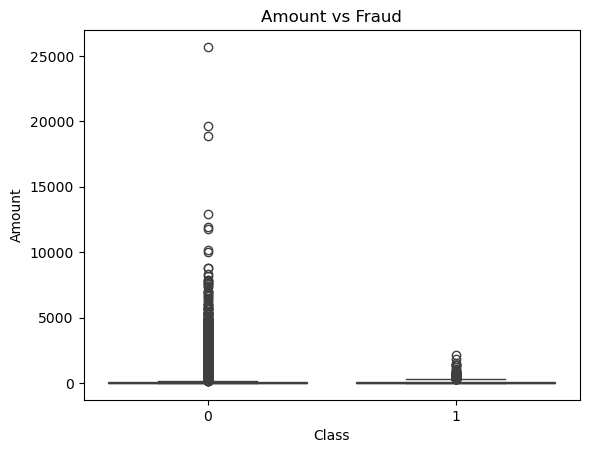

In [20]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

### 👉 Insight:

#### Fraud transactions often have unusual amounts

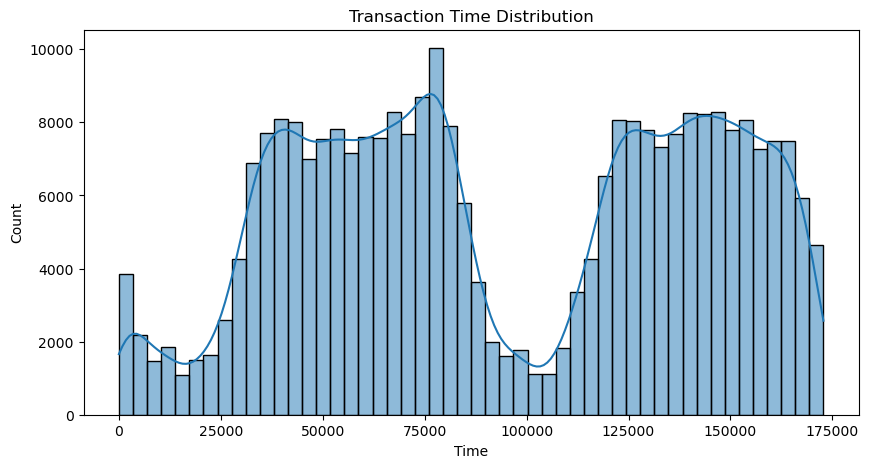

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Transaction Time Distribution")
plt.show()

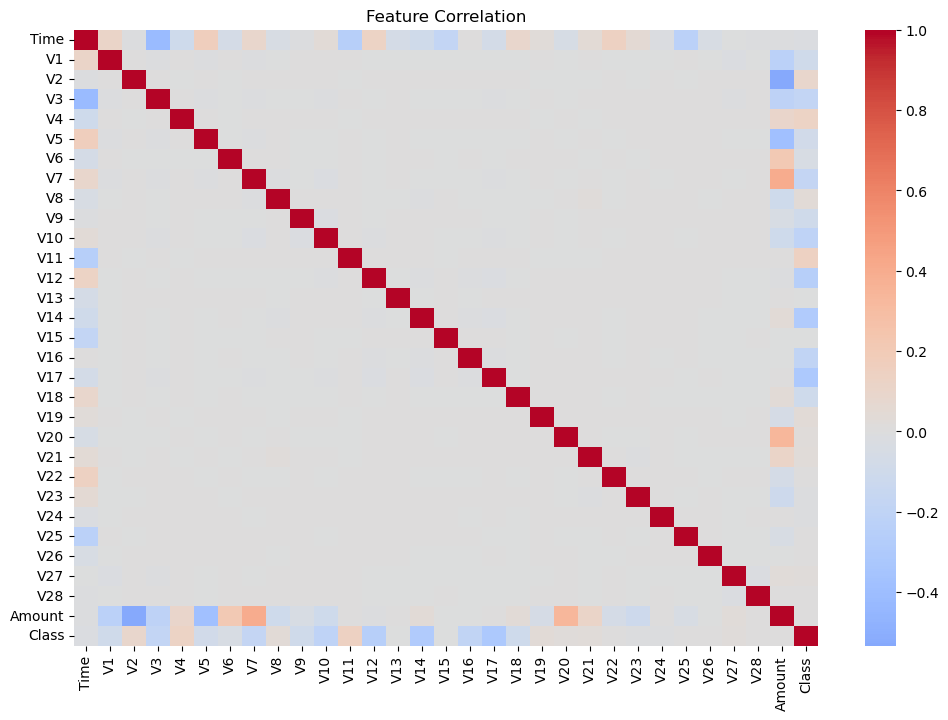

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation")
plt.show()

### 🔍 Key Insights

- The dataset is highly imbalanced with very few fraud transactions (~0.17%)
- No missing values are present
- Duplicate rows were found and removed
- Transaction amount shows variation between fraud and normal cases
- PCA-transformed features (V1–V28) show low correlation
- Accuracy is not a reliable metric due to imbalance

# Feature Engeneering

In [27]:
df['user_id'] = df.index % 1000

In [28]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,user_id,avg_amount_user,transaction_count,std_amount_user
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,109.178310,284,435.832398
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,1,87.055512,283,215.733088
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,2,77.618869,283,158.973487
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,3,75.316078,283,146.780262
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,4,86.087801,282,196.410818


In [29]:
df['avg_amount_user'] = df.groupby('user_id')['Amount'].transform('mean')
df['transaction_count'] = df.groupby('user_id')['Amount'].transform('count')
df['std_amount_user'] = df.groupby('user_id')['Amount'].transform('std')

In [30]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,user_id,avg_amount_user,transaction_count,std_amount_user
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,109.178310,284,435.832398
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,1,87.055512,283,215.733088
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,2,77.618869,283,158.973487
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,3,75.316078,283,146.780262
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,4,86.087801,282,196.410818


In [32]:
df['hour'] = (df['Time'] // 3600) % 24
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)

In [33]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V27,V28,Amount,Class,user_id,avg_amount_user,transaction_count,std_amount_user,hour,is_night
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.133558,-0.021053,149.62,0,0,109.178310,284,435.832398,0.0,1
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.008983,0.014724,2.69,0,1,87.055512,283,215.733088,0.0,1
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.055353,-0.059752,378.66,0,2,77.618869,283,158.973487,0.0,1
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.062723,0.061458,123.50,0,3,75.316078,283,146.780262,0.0,1
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.219422,0.215153,69.99,0,4,86.087801,282,196.410818,0.0,1


In [34]:
df['amount_deviation'] = abs(df['Amount'] - df['avg_amount_user'])

In [35]:
df['high_deviation'] = (df['amount_deviation'] > df['std_amount_user']).astype(int)

In [36]:
df['tx_per_user'] = df.groupby('user_id')['Time'].transform('count')

In [40]:
X = df.drop("Class",axis = 1)
y = df["Class"]

In [41]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.25)


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [46]:
pipeline = Pipeline([("sc",StandardScaler()),
                    ("model",DecisionTreeClassifier())])

In [47]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('sc', StandardScaler()), ('model', DecisionTreeClassifier())])

In [48]:
y_pred = pipeline.predict(x_test)

In [50]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report
acc = accuracy_score(y_test,y_pred)
acc
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70820
           1       0.69      0.75      0.72       112

    accuracy                           1.00     70932
   macro avg       0.85      0.87      0.86     70932
weighted avg       1.00      1.00      1.00     70932



In [52]:
from sklearn.metrics import roc_auc_score

y_prob = pipeline.predict_proba(x_test)[:,1]
roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_score)

ROC-AUC: 0.874738774357526


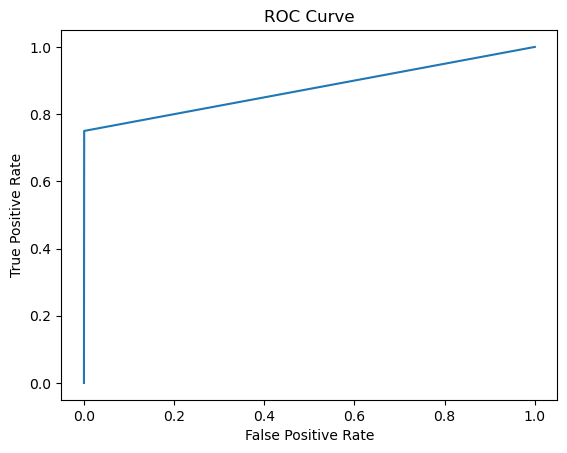

In [53]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [54]:
from sklearn.ensemble import IsolationForest

In [55]:
features = [
    'Amount', 'hour', 'amount_deviation',
    'avg_amount_user', 'std_amount_user',
    'transaction_count'
]

X_iforest = df[features]

In [56]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,   # expected fraud %
    random_state=42
)

iso_model.fit(X_iforest)

IsolationForest(contamination=0.01, random_state=42)

In [57]:
df['anomaly'] = iso_model.predict(X_iforest)

In [58]:
df['anomaly_flag'] = df['anomaly'].apply(lambda x: 1 if x == -1 else 0)

In [59]:
df['anomaly_flag'].value_counts()

anomaly_flag
0    280888
1      2838
Name: count, dtype: int64

In [60]:
pd.crosstab(df['Class'], df['anomaly_flag'])

anomaly_flag,0,1
Class,,
0,280424,2829
1,464,9


In [61]:
df['final_flag'] = ((df['anomaly_flag'] == 1) | (df['Class'] == 1)).astype(int)

In [62]:
from sklearn.metrics import classification_report

print(classification_report(df['Class'], df['anomaly_flag']))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    283253
           1       0.00      0.02      0.01       473

    accuracy                           0.99    283726
   macro avg       0.50      0.50      0.50    283726
weighted avg       1.00      0.99      0.99    283726



In [69]:
joblib.dump(pipeline, "models/fraud_model.pkl")
joblib.dump(iso_model, "models/anomaly_model.pkl")

['models/anomaly_model.pkl']

In [66]:
pip install fastapi uvicorn


  Using cached fastapi-0.136.3-py3-none-any.whl.metadata (27 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached starlette-1.2.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached fastapi-0.136.3-py3-none-any.whl (117 kB)
Using cached uvicorn-0.49.0-py3-none-any.whl (71 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached starlette-1.2.1-py3-none-any.whl (73 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)

   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ---------------- ----------------------- 2/5 [uvicorn]
   ------------------------ --------------- 3/5 [starlette]
   ------------------------ --------------- 3/5 [starlette]
   ------------------------ --------------- 3/5 [starlette]
   -------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\dasar\anaconda3\python.exe -m pip install --upgrade pip


In [71]:
# 🔥 FINAL MODEL (FOR DEPLOYMENT)

features = [
    'Amount',
    'hour',
    'avg_amount_user',
    'std_amount_user',
    'transaction_count',
    'amount_deviation'
]

X = df[features]
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

# Save final model
import joblib
joblib.dump(pipeline, "models/fraud_model.pkl")

['models/fraud_model.pkl']

In [72]:
from sklearn.ensemble import IsolationForest

X_iforest = df[features]

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

iso_model.fit(X_iforest)

joblib.dump(iso_model, "models/anomaly_model.pkl")

['models/anomaly_model.pkl']